In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Baca data yang sudah dibersihkan dari Buku 1
df = pd.read_csv('weatherAUS_cleaned.csv')
print("Dimensi data bersih:", df.shape)
df.head()

Dimensi data bersih: (142193, 20)


,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,WindDir3pm,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure3pm,Cloud9am,Cloud3pm,RainToday,RainTomorrow
0,2008-12-01,Albury,13.4,22.9,0.6,4.8,8.5,W,44.0,W,WNW,20.0,24.0,71.0,22.0,1007.1,8.0,5.0,No,No
1,2008-12-02,Albury,7.4,25.1,0.0,4.8,8.5,WNW,44.0,NNW,WSW,4.0,22.0,44.0,25.0,1007.8,5.0,5.0,No,No
2,2008-12-03,Albury,12.9,25.7,0.0,4.8,8.5,WSW,46.0,W,WSW,19.0,26.0,38.0,30.0,1008.7,5.0,2.0,No,No
3,2008-12-04,Albury,9.2,28.0,0.0,4.8,8.5,NE,24.0,SE,E,11.0,9.0,45.0,16.0,1012.8,5.0,5.0,No,No
4,2008-12-05,Albury,17.5,32.3,1.0,4.8,8.5,W,41.0,ENE,NW,7.0,20.0,82.0,33.0,1006.0,7.0,8.0,No,No


In [3]:
# 1. Pastikan target berupa biner 0 dan 1
if df['RainTomorrow'].dtype == 'object':
    df['RainTomorrow'] = df['RainTomorrow'].map({'No': 0, 'Yes': 1})

if 'RainToday' in df.columns and df['RainToday'].dtype == 'object':
    df['RainToday'] = df['RainToday'].map({'No': 0, 'Yes': 1})

# 2. Pisahkan X (fitur input) dan y (target output)
X = df.drop(columns=['RainTomorrow', 'Date'], errors='ignore')
y = df['RainTomorrow']

# 3. One-Hot Encoding untuk sisa kolom kategorikal (Location, WindDir)
cat_cols = X.select_dtypes(include=['object']).columns.tolist()
X = pd.get_dummies(X, columns=cat_cols, drop_first=True)

print("Dimensi fitur X:", X.shape)
print("Distribusi target y:\n", y.value_counts())

Dimensi fitur X: (142193, 107)
Distribusi target y:
 RainTomorrow
0    110316
1     31877
Name: count, dtype: int64


In [4]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Jumlah data latih: {X_train.shape[0]:,} baris")
print(f"Jumlah data uji: {X_test.shape[0]:,} baris")

Jumlah data latih: 113,754 baris
Jumlah data uji: 28,439 baris


In [5]:
\from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Identifikasi kolom numerik kontinu (bukan hasil dummy 0/1)
numeric_features = [col for col in X_train.columns if X_train[col].nunique() > 2]

# Scaling hanya pada fitur numerik
X_train[numeric_features] = scaler.fit_transform(X_train[numeric_features])
X_test[numeric_features] = scaler.transform(X_test[numeric_features])

print("Contoh hasil scaling pada data latih:")
X_train[numeric_features].head(3)

Contoh hasil scaling pada data latih:


,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure3pm,Cloud9am,Cloud3pm
101064,1.115138,1.628590,-0.274820,2.963283,1.609865,1.227565,0.116645,-1.336036,-0.890073,-1.534456,-0.697176,-0.717586,-0.802866
18241,-0.026927,-0.086820,-0.251304,-0.123166,0.165467,-0.067922,-0.337013,0.385061,0.060579,0.023475,0.560479,0.153571,0.140462
96741,0.129520,0.025666,-0.274820,-0.123166,0.165467,0.236898,-1.357742,0.385061,-0.256305,-0.366008,-0.727120,0.153571,0.140462


In [6]:
from imblearn.over_sampling import SMOTE

print("Distribusi kelas sebelum SMOTE:")
print(y_train.value_counts())

smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print("\nDistribusi kelas setelah SMOTE:")
print(y_train_res.value_counts())

Distribusi kelas sebelum SMOTE:
RainTomorrow
0    88252
1    25502
Name: count, dtype: int64

Distribusi kelas setelah SMOTE:
RainTomorrow
0    88252
1    88252
Name: count, dtype: int64


In [7]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report

# 1. Menyiapkan daftar model yang akan diuji
models = {
    "Logistic Regression": LogisticRegression(random_state=42, max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
}

# Variabel untuk menyimpan model terbaik
best_model = None
best_f1_score = 0
best_model_name = ""
best_y_pred = None # Menyimpan hasil prediksi dari model terbaik

# 2. Melatih dan mengevaluasi setiap model secara otomatis
for model_name, model in models.items():

    # Melatih model dengan data yang sudah di-SMOTE
    model.fit(X_train_res, y_train_res)

    # Memprediksi data uji
    y_pred = model.predict(X_test)

    # Menghitung metrik
    acc = accuracy_score(y_test, y_pred)
    f1_kelas_1 = f1_score(y_test, y_pred) # F1-score khusus untuk kelas 1 (Hujan)
    report = classification_report(y_test, y_pred)

    # Menampilkan output
    print(f"▶ Model: {model_name}")
    print(f"Akurasi Keseluruhan: {acc * 100:.2f}%")
    print(f"F1-Score Kelas Hujan (1): {f1_kelas_1 * 100:.2f}%")
    print("Laporan Klasifikasi Lengkap:")
    print(report)
    print("-" * 40 + "\n")

    # 3. Logika memilih model terbaik (Berdasarkan F1-Score tertinggi)
    if f1_kelas_1 > best_f1_score:
        best_f1_score = f1_kelas_1
        best_model = model
        best_model_name = model_name
        best_y_pred = y_pred

print(f"🌟 MODEL TERBAIK: {best_model_name} (F1-Score: {best_f1_score * 100:.2f}%)")

# Memasukkan model terbaik ke variabel rf_model agar kode visualisasi Anda selanjutnya tetap berjalan
rf_model = best_model
y_pred = best_y_pred

▶ Model: Logistic Regression
Akurasi Keseluruhan: 82.37%
F1-Score Kelas Hujan (1): 61.30%
Laporan Klasifikasi Lengkap:
              precision    recall  f1-score   support

           0       0.89      0.88      0.89     22064
           1       0.60      0.62      0.61      6375

    accuracy                           0.82     28439
   macro avg       0.75      0.75      0.75     28439
weighted avg       0.83      0.82      0.82     28439

----------------------------------------

▶ Model: Decision Tree
Akurasi Keseluruhan: 77.54%
F1-Score Kelas Hujan (1): 53.35%
Laporan Klasifikasi Lengkap:
              precision    recall  f1-score   support

           0       0.87      0.83      0.85     22064
           1       0.50      0.57      0.53      6375

    accuracy                           0.78     28439
   macro avg       0.69      0.70      0.69     28439
weighted avg       0.79      0.78      0.78     28439

----------------------------------------

▶ Model: Random Forest
Akurasi

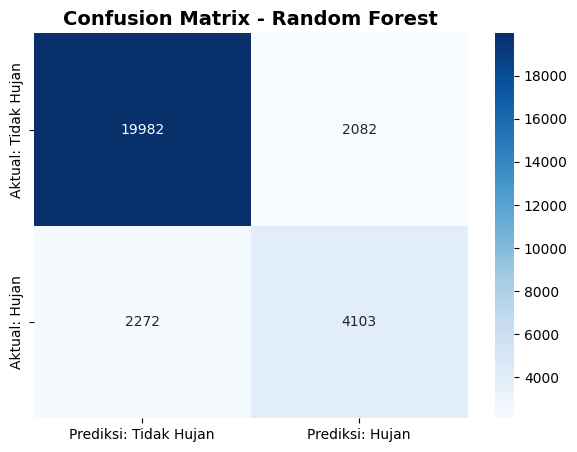

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Membuat Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Prediksi: Tidak Hujan', 'Prediksi: Hujan'],
            yticklabels=['Aktual: Tidak Hujan', 'Aktual: Hujan'])

plt.title('Confusion Matrix - Random Forest', fontsize=14, fontweight='bold')
plt.show()

/tmp/ipykernel_1246/721288844.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feature_importances.head(10), x='Tingkat Kepentingan', y='Fitur', palette='viridis')


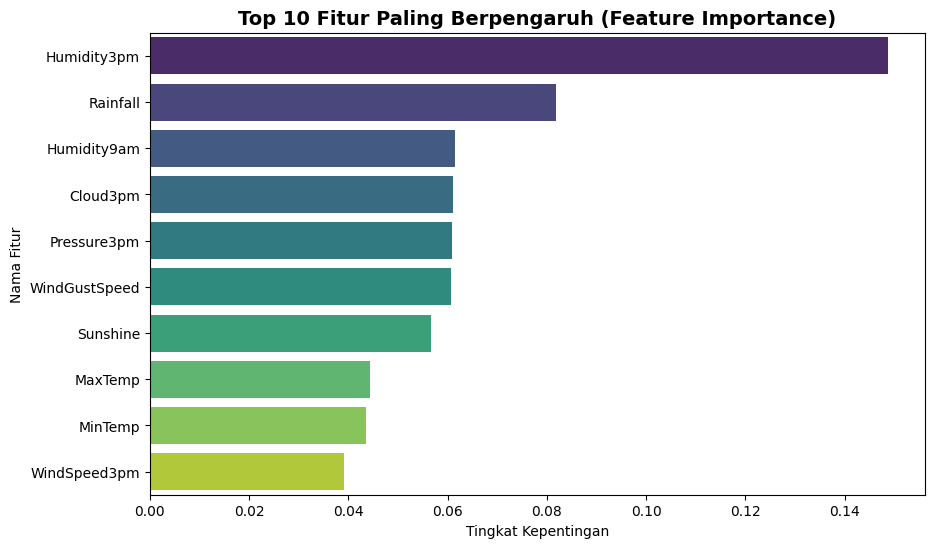

In [9]:
# Mengekstrak nilai Feature Importance dari model
feature_importances = pd.DataFrame({
    'Fitur': X_train_res.columns,
    'Tingkat Kepentingan': rf_model.feature_importances_
}).sort_values(by='Tingkat Kepentingan', ascending=False)

# Visualisasi 10 fitur paling berpengaruh
plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importances.head(10), x='Tingkat Kepentingan', y='Fitur', palette='viridis')

plt.title('Top 10 Fitur Paling Berpengaruh (Feature Importance)', fontsize=14, fontweight='bold')
plt.xlabel('Tingkat Kepentingan')
plt.ylabel('Nama Fitur')
plt.show()

In [10]:
import joblib

# 1. Simpan Model Random Forest (Atau model terbaik Anda)
joblib.dump(rf_model, 'model_cuaca_rf.pkl')
print("Model berhasil disimpan ke penyimpanan lokal sementara.")

from google.colab import files
files.download('model_cuaca_rf.pkl')

Model dan Scaler berhasil disimpan ke penyimpanan lokal sementara.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>